# **Лабораторная работа №1. Работа с библиотекой Gym**

https://www.gymlibrary.dev/environments/toy_text/frozen_lake/

Работу выполнили:
- Расковалова Алёна, P4241
- Строкова Анастасия, P4240

In [ ]:
# Установка необходимых библиотек
!pip install gymnasium[all]
!pip install autorom[accept-rom-license]
!pip install stable-baselines3
!pip install PyVirtualDisplay
!sudo apt-get install xvfb

In [ ]:
# Импорт необходимых пакетов
import gymnasium as gym
from stable_baselines3 import DQN

In [ ]:
# Создание среды FrozenLake
env = gym.make('FrozenLake-v1',map_name="8x8", is_slippery=False)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Описание задачи
# observation space - пространство наблюдения
# action space - пространство действий
observation_space = env.observation_space
action_space = env.action_space

In [ ]:
# Инициализация модели DQN
model = DQN("MlpPolicy", env, verbose=1)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
# Обучение модели
timestamp=1000000
model.learn(total_timesteps=timestamp, log_interval=100000)
# Сохранение обученной модели в файл "dnq_cartpole"
model.save("dqn_cartpole")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
actions = []
rewards = []

In [ ]:
# пакет для визуализации среды в Colab
!sudo apt-get install xvfb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.5).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


[array(1), array(2), array(2), array(1), array(3), array(1), array(1), array(2), array(2), array(1), array(2), array(2), array(2), array(1), array(1), array(1)] [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]


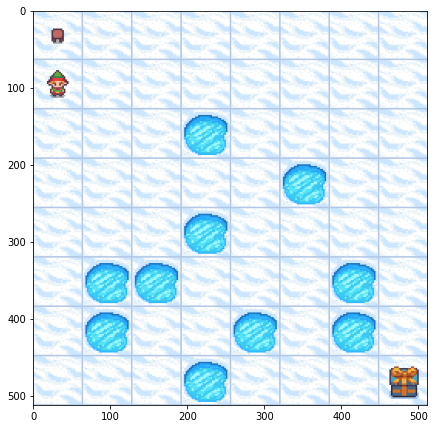

In [ ]:
# Импорт библиотек
import gym
from IPython import display
from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
from matplotlib import animation

# Запуск виртуального дисплея
d = Display()
d.start()

# Создание среды FrozenLake для тестирования
# Поле имеет размер 8х8
env = gym.make('FrozenLake-v1',map_name="8x8", is_slippery=False)

# Сброс среды и получение начального наблюдения
obs = env.reset()

# Цикл, в котором модель используется для прогнозирования действия
# Действие применяется к среде
# Текущий кадр среды записывается в виде изображения для создания анимации

# Запись изображения для создания анимации
img = []
for _ in range(1000):
    # Прогноз действия с использованием обученной модели
    action, _states = model.predict(obs)
    # Применение действия к среде
    obs, reward, terminated, truncated = env.step(int(action))
    rewards.append(reward)
    actions.append(action)
    # Очистка вывода для анимации
    display.clear_output(wait=True)
    # Запись текущего кадра среды в виде изображения
    img.append(env.render('rgb_array'))
    # Сброс среды, если используется виртуальный дисплей
    if terminated:
        print(actions, rewards)
        env.reset()
        break

# Параметры для создания анимации
dpi = 72
interval = 75 # ms

# Создание и отображение анимации
plt.figure(figsize=(img[0].shape[1]/dpi,img[0].shape[0]/dpi),dpi=dpi)
patch = plt.imshow(img[0])
plt.axis=('off')
animate = lambda i: patch.set_data(img[i])
ani = animation.FuncAnimation(plt.gcf(),animate,frames=len(img),interval=interval)
display.display(display.HTML(ani.to_jshtml()))

In [ ]:
# Закрытие среды после тестирования
env.close()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


**Вывод**

Таким образом, в рамках лабораторной работы было продемонстрировано использование библиотек для работы с окружением OpenAI Gym, обучение модели глубокого обучения на примере задачи FrozenLake и визуализация результатов обучения в Collab с использованием анимации.

Выполнена следующая последовательность действий:
- Установка библиотек для работы над лабораторной работы (Gym, Stable-Baselines3, PyVirtualDisplay, Xvfb)
- Импорт и настройка окружения (извлечение пространства наблюдений и пространства действий из среды FrozenLake)
- Обучение модели (использован алгоритм DQN)
- Анимация и вывод результатов на дисплей
- Закрытие среды для освобождения ресурсов.